In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
np.random.seed(0)
x = np.linspace(-5, 5, 50) 
y = 2*x**2 + 3*x + np.random.randn(50)*10 # y = 2x^2 + 3x + error 

In [3]:
degree = 2
coefficients = np.polyfit(x, y, degree)
print(coefficients)

[2.09218103 1.58837751 0.60606342]


In [5]:
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)

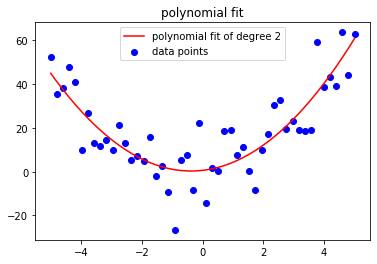

In [10]:
plt.scatter(x, y, color = "blue", label = "data points")
plt.plot(x, y_pred, color = "red", label=f"polynomial fit of degree {degree}")
plt.title("polynomial fit")
plt.legend()
plt.show()

In [12]:
# mean squared error 
mse = np.mean((y-y_pred)**2)
print(f'mean squared error: {mse:0.4f}')

#r squared 
ss_total = np.sum((y-np.mean(y))**2)
ss_res = np.sum((y-y_pred)**2)
r_squared = 1 - (ss_res/ss_total)
print(f'R-squared: {r_squared: 0.4f}')

mean squared error: 108.8860
R-squared:  0.7236


In [18]:
#vandermode matrix 

x = np.array([1, 2, 3])
degree = 2
y = x**degree

def create_vandermonde_matrix(x, degree):
    return np.vander(x, N=degree+1, increasing=True)

V = create_vandermonde_matrix(x, degree)
print(V)

VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, y)

coefficients = np.linalg.solve(VT_V, VT_y)
print(coefficients)

y_pred = np.dot(V, coefficients)
print(y_pred)

[[1 1 1]
 [1 2 4]
 [1 3 9]]
[-1.83979816e-14  2.17603713e-14  1.00000000e+00]
[1. 4. 9.]


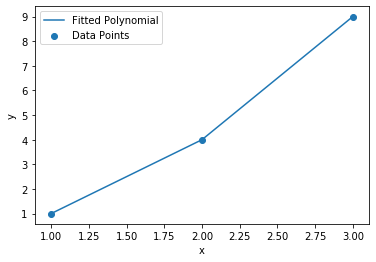

In [19]:
plt.scatter(x, y, label="Data Points")
plt.plot(x, y_pred, label="Fitted Polynomial")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()